In [1]:
!pwd

/home/hgkahng/Workspaces/soft-prompt/notebooks/agnews


In [24]:
import os
import sys
sys.path.insert(
    0, os.path.abspath("../../")
)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
root_dir = Path("../../").resolve()
write_dir = root_dir / "data/agnews/"
print(f"Data will be saved to:\n{write_dir}")

Data will be saved to:
/home/hgkahng/Workspaces/soft-prompt/data/agnews


In [5]:
if not write_dir.exists():
    write_dir.mkdir()
    print(f"Directory created.")
else:
    print(f"Warning: {write_dir} already exists.")

Directory created.


In [6]:
from datasets import load_dataset

In [7]:
ds = load_dataset("SetFit/ag_news", trust_remote_code=True)

train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})

In [17]:
ds['train'][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2,
 'label_text': 'Business'}

In [9]:
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

# Basic Cleaning

In [11]:
import re
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r'""', '"', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub('\s+', ' ', text).strip()
    return text

In [18]:
df_train.head()

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [19]:
%%time
df_train['cleaned_text'] = df_train['text'].apply(clean_text)

CPU times: user 790 ms, sys: 5.09 ms, total: 795 ms
Wall time: 795 ms


In [20]:
df_train.head()

,text,label,label_text,cleaned_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",2,Business,oil prices soar to alltime record posing new m...


In [21]:
df_test.head()

,text,label,label_text
0,Fears for T N pension after talks Unions repre...,2,Business
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech


In [22]:
%%time
df_test['cleaned_text'] = df_test['text'].apply(clean_text)

CPU times: user 50.1 ms, sys: 1.01 ms, total: 51.1 ms
Wall time: 50.6 ms


In [23]:
df_test.head()

,text,label,label_text,cleaned_text
0,Fears for T N pension after talks Unions repre...,2,Business,fears for t n pension after talks unions repre...
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech,the race is on second private team sets launch...
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech,ky company wins grant to study peptides ap ap ...
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech,prediction unit helps forecast wildfires ap ap...
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech,calif aims to limit farmrelated smog ap ap sou...


In [44]:
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-4o")

In [45]:
df_train['num_tokens'] = [len(r) for r in encoding.encode_batch(df_train['cleaned_text'])]
df_test['num_tokens'] = [len(r) for r in encoding.encode_batch(df_test['cleaned_text'])]

In [46]:
df_train['split'] = 'train'
df_test['split'] = 'test'

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

In [47]:
df.head()

,text,label,label_text,cleaned_text,num_tokens,split
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,wall st bears claw back into the black reuters...,28,train
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,carlyle looks toward commercial aerospace reut...,48,train
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,oil and economy cloud stocks outlook reuters r...,42,train
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,iraq halts oil exports from main southern pipe...,45,train
4,"Oil prices soar to all-time record, posing new...",2,Business,oil prices soar to alltime record posing new m...,42,train


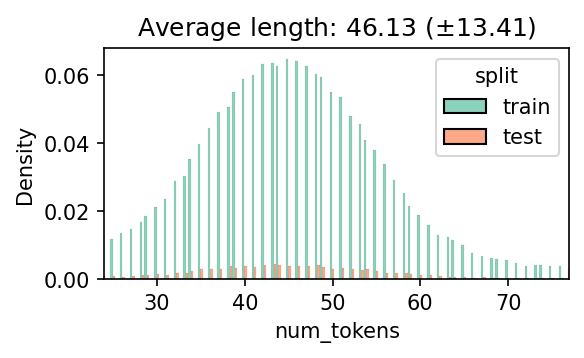

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=150)
sns.histplot(data=df, x='num_tokens', hue='split', palette="Set2", alpha=.75,
             stat='density',
             edgecolor='k', shrink=1.0, bins='auto', multiple='dodge', ax=ax)
ax.set_title(
    f"Average length: {df['num_tokens'].mean():.2f} ($\pm${df['num_tokens'].std(ddof=1):.2f})"
)

lower_limit = df['num_tokens'].quantile(0.025)
upper_limit = df['num_tokens'].quantile(0.975)
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

## Compute Embeddings
- Model: `text-embedding-3-small`

In [26]:
from softprompt.embeddings import compute_openai_embeddings

import logging
logging.basicConfig(level=logging.WARNING)

In [ ]:
import openai
from dotenv import load_dotenv

load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

In [29]:
embeddings_tr = await compute_openai_embeddings(
    df_train['cleaned_text'],
    batch_size=50,
)

/tmp/ipykernel_749249/233558891.py:1: RuntimeWarning: coroutine 'compute_openai_embeddings' was never awaited
  embeddings_tr = await compute_openai_embeddings(


In [30]:
embeddings_te = await compute_openai_embeddings(
    df_test['cleaned_text'],
    batch_size=50,
)

In [34]:
df_train.columns

Index(['text', 'label', 'label_text', 'cleaned_text'], dtype='object')

In [36]:
y_train = df_train['label'].values

In [37]:
df_test.columns

Index(['text', 'label', 'label_text', 'cleaned_text'], dtype='object')

In [38]:
y_test = df_test['label'].values

In [39]:
write_dir

PosixPath('/home/hgkahng/Workspaces/soft-prompt/data/agnews')

In [41]:
emb_save_dir = write_dir / "embeddings/openai/text-embedding-3-small"
if not emb_save_dir.exists():
    os.makedirs(emb_save_dir, exist_ok=False)
    print(f"Created directory:\n{emb_save_dir}")

Created directory:
/home/hgkahng/Workspaces/soft-prompt/data/agnews/embeddings/openai/text-embedding-3-small


In [42]:
np.save(emb_save_dir / "train.features.npy", embeddings_tr)
np.save(emb_save_dir / "train.labels.npy", y_train)
np.save(emb_save_dir / "test.features.npy", embeddings_te)
np.save(emb_save_dir / "test.labels.npy", y_test)